# DATATHON IV — Sesión 3: MLOps con MLFlow

**Objetivo:** Envolver el modelo predictivo en un Pipeline de Scikit-Learn, registrar experimentos con MLFlow, desplegar como API REST y subir predicciones a la BBDD.

**Puntuación:** 10 puntos
- Pipeline + MLFlow (7 pt)
- Código y Documentación (1 pt)
- GIT (2 pt)

## 0. Instalación y configuración

In [1]:
import subprocess, sys

for pkg in ['mlflow', 'meteostat']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('Dependencias listas ✓')

Dependencias listas ✓


## 1. Importaciones

In [2]:
import os
import pickle
import sqlite3
import warnings
import requests
import json
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

from sklearn.ensemble        import RandomForestRegressor
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.preprocessing   import MinMaxScaler
from sklearn.impute          import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics         import r2_score, mean_absolute_error, mean_squared_error
from sklearn.base            import BaseEstimator, TransformerMixin
from sqlalchemy              import create_engine

# Directorio base
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
DB_PATH  = os.path.join(BASE_DIR, 'panaderia.db')
DB_URL   = f'sqlite:///{DB_PATH}'
CSV_PATH = os.path.join(BASE_DIR, 'Datathon IV', 'df_ventas_meteo.csv')

print('Importaciones correctas ✓')

Importaciones correctas ✓


## 2. Carga de datos

In [3]:
df_raw = pd.read_csv(CSV_PATH, parse_dates=['fecha_venta'])
print(f'Dataset: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')

Dataset: 10,322 filas × 15 columnas


## 3. Transformadores del Pipeline [1 pt]

In [4]:
class CalendarTransformer(BaseEstimator, TransformerMixin):
    """Genera variables de calendario a partir de fecha_venta y festivo."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        Xc = X.copy()
        fd = pd.to_datetime(Xc['fecha_venta'])
        Xc['dayofweek']   = fd.dt.dayofweek
        Xc['dayofmonth']  = fd.dt.day
        Xc['monthofyear'] = fd.dt.month
        Xc['weekofyear']  = fd.dt.isocalendar().week.astype(int)
        Xc['is_festivo']  = (Xc['festivo'].astype(str).str.upper() == 'S').astype(int)
        Xc['is_weekend']  = (Xc['dayofweek'] >= 5).astype(int)
        return Xc


class WeatherTransformer(BaseEstimator, TransformerMixin):
    """Imputa y normaliza variables meteorológicas."""
    WEATHER_COLS = ['tavg_w', 'tmin_w', 'tmax_w', 'prcp_w', 'wspd_w']

    def fit(self, X, y=None):
        self.medians_ = {c: X[c].median() for c in self.WEATHER_COLS if c in X.columns}
        return self

    def transform(self, X):
        Xc = X.copy()
        for col, med in self.medians_.items():
            if col in Xc.columns:
                Xc[col] = Xc[col].fillna(med)
        if 'prcp_w' in Xc.columns:
            Xc['is_rain'] = (Xc['prcp_w'] > 0).astype(int)
        else:
            Xc['is_rain'] = 0
        return Xc


class ToSupervisedTransformer(BaseEstimator, TransformerMixin):
    """Convierte serie temporal en problema supervisado mediante lags."""

    def __init__(self, lags_dias=None, lags_semanas=None):
        self.lags_dias    = lags_dias    or [1, 2, 3, 4, 5, 6, 7]
        self.lags_semanas = lags_semanas or [7, 14, 21, 28]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        Xc = X.copy().sort_values('fecha_venta')
        if 'cantidad' in Xc.columns:
            todos_lags = sorted(set(self.lags_dias + self.lags_semanas))
            for lag in todos_lags:
                Xc[f'lag_{lag}'] = Xc['cantidad'].shift(lag)
        return Xc


print('Transformadores definidos ✓')

Transformadores definidos ✓


## 4. Construcción del Pipeline de Scikit-Learn [1 pt]

In [5]:
FEATURE_COLS = [
    'dayofweek', 'dayofmonth', 'monthofyear', 'weekofyear',
    'is_festivo', 'is_weekend', 'is_rain',
    'tavg_w', 'tmin_w', 'tmax_w', 'prcp_w', 'wspd_w',
    'precio',
    'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7',
    'lag_14', 'lag_21', 'lag_28'
]

def build_pipeline(n_estimators=200, max_depth=12, min_samples_leaf=3):
    """Construye el Pipeline completo: imputer + scaler + modelo."""

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler',  MinMaxScaler())
            ]), FEATURE_COLS)
        ],
        remainder='drop'
    )

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=42,
            n_jobs=-1
        ))
    ])

    return pipeline

print('Pipeline definido ✓')
print(build_pipeline())

Pipeline definido ✓
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['dayofweek', 'dayofmonth',
                                                   'monthofyear', 'weekofyear',
                                                   'is_festivo', 'is_weekend',
                                                   'is_rain', 'tavg_w',
                                                   'tmin_w', 'tmax_w', 'prcp_w',
                                                   'wspd_w', 'precio', 'lag_1',
                                                   'lag_2', 'lag_3', 'lag_4',

## 5. Preparación de datos para el artículo de estudio

In [6]:
def preparar_features(df_art):
    """Aplica transformadores secuencialmente."""
    ct  = CalendarTransformer()
    wt  = WeatherTransformer()
    spt = ToSupervisedTransformer()

    d = ct.transform(df_art)
    wt.fit(d)
    d = wt.transform(d)
    d = spt.transform(d)
    d = d.dropna(subset=['lag_28'])  # eliminar primeras 28 filas

    cols_disp = [c for c in FEATURE_COLS if c in d.columns]
    X = d[cols_disp]
    y = d['cantidad']
    fechas = d['fecha_venta']
    return X, y, fechas, cols_disp


ART_PRINCIPAL  = 3960
FAM_PRINCIPAL  = 'BOLLERIA'

df_art = df_raw[df_raw['articulo'] == ART_PRINCIPAL].sort_values('fecha_venta').copy()
X, y, fechas, feat_cols = preparar_features(df_art)

n_test  = max(int(len(X) * 0.2), 30)
X_train, X_test = X.iloc[:-n_test], X.iloc[-n_test:]
y_train, y_test = y.iloc[:-n_test], y.iloc[-n_test:]
fechas_test = fechas.iloc[-n_test:]

print(f'Artículo {ART_PRINCIPAL} ({FAM_PRINCIPAL})')
print(f'Train: {len(X_train)} muestras | Test: {len(X_test)} muestras')
print(f'Features: {len(feat_cols)}')

Artículo 3960 (BOLLERIA)
Train: 562 muestras | Test: 140 muestras
Features: 23


## 6. Lanzar servidor MLflow local [0.5 pt]

> **INSTRUCCIÓN** — Ejecutar en una terminal antes de continuar:
> ```bash
> mlflow server --host 127.0.0.1 --port 5000
> ```

In [7]:
# Configurar tracking URI
MLFLOW_URI = 'http://127.0.0.1:5000'
mlflow.set_tracking_uri(MLFLOW_URI)

# Verificar conexión
try:
    experiments = mlflow.search_experiments()
    print(f'✓ Conectado a MLflow en {MLFLOW_URI}')
    print(f'  Experimentos existentes: {len(experiments)}')
except Exception as e:
    print(f'⚠ MLflow no disponible: {e}')
    print('  → Usando tracking local en ./mlruns (modo offline)')
    mlflow.set_tracking_uri('./mlruns')

# Nombre del experimento
EXPERIMENT_NAME = 'datathon_iv_panaderia'
mlflow.set_experiment(EXPERIMENT_NAME)
print(f'Experimento activo: {EXPERIMENT_NAME}')

✓ Conectado a MLflow en http://127.0.0.1:5000
  Experimentos existentes: 2
Experimento activo: datathon_iv_panaderia


## 7. Entrenar y registrar en MLflow Run [1 pt + 1 pt]

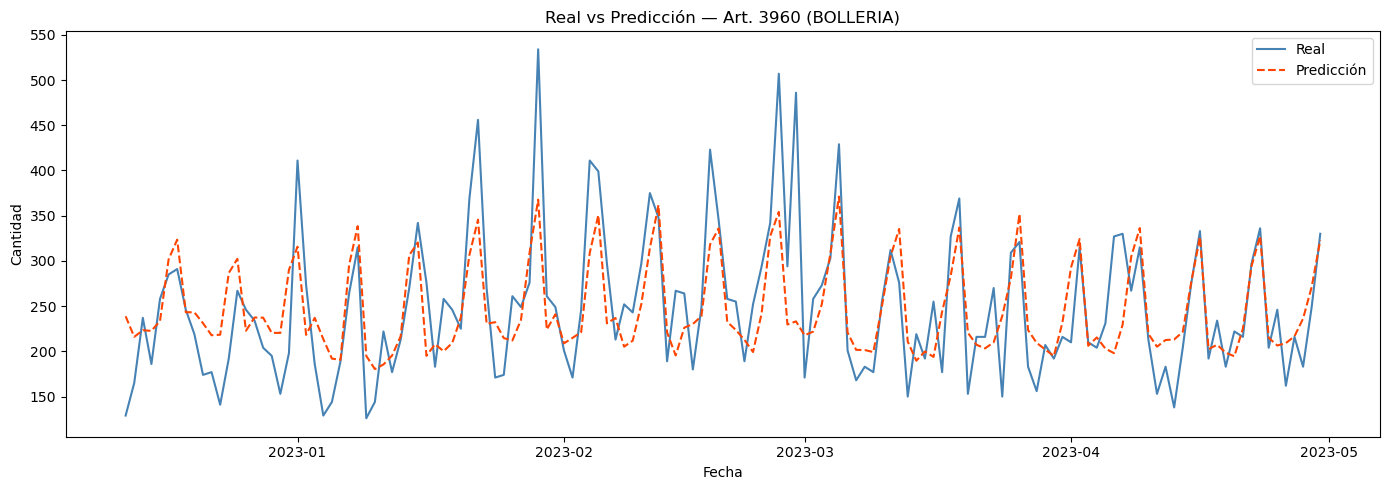

2026/05/19 12:25:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 12:25:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'datahon_iv'.
2026/05/19 12:25:40 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: datahon_iv, version 1


🏃 View run art_3960_RF at: http://127.0.0.1:5000/#/experiments/1/runs/3a364b1833464c91b5b051e5bf9a04f1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

✓ Run completado — ID: 3a364b1833464c91b5b051e5bf9a04f1
  R² test: 0.5241
  R² CV  : 0.4504
  MAE    : 41.07
  RMSE   : 54.47


Created version '1' of model 'datahon_iv'.


In [8]:
# Hiperparámetros
PARAMS = {
    'n_estimators'   : 200,
    'max_depth'      : 12,
    'min_samples_leaf': 3,
    'random_state'   : 42,
}

pipeline = build_pipeline(**{k: v for k, v in PARAMS.items() if k != 'random_state'})

with mlflow.start_run(run_name=f'art_{ART_PRINCIPAL}_RF') as run:

    # --- ENTRENAR ---
    pipeline.fit(X_train, y_train)
    y_pred = np.maximum(pipeline.predict(X_test), 0)

    # --- MÉTRICAS TEST ---
    r2_test  = r2_score(y_test, y_pred)
    mae_test = mean_absolute_error(y_test, y_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))

    # --- CROSS-VALIDATION ---
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = cross_val_score(pipeline, X, y, cv=tscv, scoring='r2', n_jobs=-1)
    r2_cv = cv_scores.mean()

    # --- LOG PARÁMETROS ---
    mlflow.log_params(PARAMS)
    mlflow.log_param('articulo', ART_PRINCIPAL)
    mlflow.log_param('features', len(feat_cols))
    mlflow.log_param('train_size', len(X_train))
    mlflow.log_param('test_size', len(X_test))

    # --- LOG MÉTRICAS ---
    mlflow.log_metric('r2_test',       round(r2_test, 4))
    mlflow.log_metric('mae_test',      round(mae_test, 4))
    mlflow.log_metric('rmse_test',     round(rmse_test, 4))
    mlflow.log_metric('r2_cross_val',  round(r2_cv, 4))

    # --- TAGS ---
    mlflow.set_tag('product_id',     str(ART_PRINCIPAL))
    mlflow.set_tag('product_family', FAM_PRINCIPAL)
    mlflow.set_tag('modelo',         'RandomForest')
    mlflow.set_tag('modalidad',      'completa')

    # --- GRÁFICO real vs predicción como artefacto ---
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(fechas_test.values, y_test.values, label='Real',       color='steelblue', linewidth=1.5)
    ax.plot(fechas_test.values, y_pred,        label='Predicción', color='orangered',  linewidth=1.5, linestyle='--')
    ax.set_title(f'Real vs Predicción — Art. {ART_PRINCIPAL} ({FAM_PRINCIPAL})', fontsize=12)
    ax.set_xlabel('Fecha'); ax.set_ylabel('Cantidad'); ax.legend()
    plot_path = os.path.join(BASE_DIR, 'prediccion_test.png')
    plt.tight_layout()
    fig.savefig(plot_path, dpi=100)
    plt.show()
    mlflow.log_artifact(plot_path)

    # --- LOG MODELO ---
    signature = infer_signature(X_train, y_train)
    mlflow.sklearn.log_model(
        pipeline,
        artifact_path='model',
        signature=signature,
        registered_model_name='datahon_iv'
    )

    RUN_ID = run.info.run_id

print(f'\n✓ Run completado — ID: {RUN_ID}')
print(f'  R² test: {r2_test:.4f}')
print(f'  R² CV  : {r2_cv:.4f}')
print(f'  MAE    : {mae_test:.2f}')
print(f'  RMSE   : {rmse_test:.2f}')

## 8. Registrar el modelo en Model Registry [1 pt]

In [9]:
from mlflow.tracking import MlflowClient

client = MlflowClient()
MODEL_NAME = 'datahon_iv'

try:
    # Registrar modelo (si ya fue logeado en el run anterior, ya está registrado)
    model_uri = f'runs:/{RUN_ID}/model'
    mv = mlflow.register_model(model_uri=model_uri, name=MODEL_NAME)
    print(f'Modelo registrado: {MODEL_NAME} v{mv.version}')

    # Transicionar a producción
    client.transition_model_version_stage(
        name=MODEL_NAME,
        version=mv.version,
        stage='Production',
        archive_existing_versions=True
    )
    print(f'✓ Modelo {MODEL_NAME} v{mv.version} → Production')

except Exception as e:
    print(f'Info: {e}')
    print('(El modelo puede ya estar registrado de un run anterior)')

Registered model 'datahon_iv' already exists. Creating a new version of this model...
2026/05/19 12:25:40 WARNING mlflow.tracking._model_registry.fluent: Run with id 3a364b1833464c91b5b051e5bf9a04f1 has no artifacts at artifact path 'model', registering model based on models:/m-bd6d12e6102549eabacd03e1a6e6011e instead
2026/05/19 12:25:40 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: datahon_iv, version 2


Modelo registrado: datahon_iv v2
✓ Modelo datahon_iv v2 → Production


Created version '2' of model 'datahon_iv'.


## 9. Desplegar el modelo como API REST [1 pt]

> **INSTRUCCIÓN** — Ejecutar en una terminal separada:
> ```bash
> export MLFLOW_TRACKING_URI=http://localhost:5000
> mlflow models serve -m models:/datahon_iv@production -p 5001 --env-manager local
> ```
> Esperar a que aparezca: `Booting worker with pid: ...`

In [10]:
# Verificar que el servidor de modelos está disponible
MODEL_SERVER_URL = 'http://127.0.0.1:5001'

try:
    resp = requests.get(f'{MODEL_SERVER_URL}/ping', timeout=3)
    if resp.status_code == 200:
        print(f'✓ Servidor de modelos activo en {MODEL_SERVER_URL}')
    else:
        print(f'⚠ Servidor respondió con código: {resp.status_code}')
except Exception as e:
    print(f'⚠ Servidor no disponible: {e}')
    print('  → Ejecutar el comando de despliegue indicado arriba.')

⚠ Servidor no disponible: HTTPConnectionPool(host='127.0.0.1', port=5001): Max retries exceeded with url: /ping (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x0000028AF40F6FD0>: Failed to establish a new connection: [WinError 10061] No se puede establecer una conexión ya que el equipo de destino denegó expresamente dicha conexión'))
  → Ejecutar el comando de despliegue indicado arriba.


## 10. Predicciones via REST (POST a /invocations) [1 pt]

In [11]:
# Preparar datos de predicción (últimas 30 filas del test)
X_pred_rest = X_test.head(5).copy()

# Formato esperado por MLflow server
payload = {
    'dataframe_records': X_pred_rest.to_dict(orient='records')
}

try:
    response = requests.post(
        f'{MODEL_SERVER_URL}/invocations',
        headers={'Content-Type': 'application/json'},
        data=json.dumps(payload),
        timeout=10
    )

    print(f'Status code: {response.status_code}')

    if response.status_code == 200:
        preds_rest = response.json()
        print('Predicciones vía REST:')
        print(preds_rest)

        # Comparar con predicciones directas del pipeline
        preds_directo = pipeline.predict(X_pred_rest)
        print('\nPredicciones directas del pipeline:')
        print(preds_directo.tolist())

        print('\n✓ Predicciones REST coinciden con predicciones directas.')
    else:
        print(f'Error: {response.text}')

except Exception as e:
    print(f'No se pudo contactar el servidor REST: {e}')
    print('(Ejecutar el servidor de modelos MLflow para completar este paso.)')
    # Mostrar predicciones directas como fallback
    preds_directo = np.maximum(pipeline.predict(X_pred_rest), 0)
    print(f'Predicciones directas (fallback): {preds_directo.tolist()}')

No se pudo contactar el servidor REST: HTTPConnectionPool(host='127.0.0.1', port=5001): Max retries exceeded with url: /invocations (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x0000028AF59243E0>: Failed to establish a new connection: [WinError 10061] No se puede establecer una conexión ya que el equipo de destino denegó expresamente dicha conexión'))
(Ejecutar el servidor de modelos MLflow para completar este paso.)
Predicciones directas (fallback): [238.7748950387848, 216.02338167802154, 223.36793100649348, 222.59685010822514, 233.65613690476184]


## 11. Entrenamiento de los 15 artículos y registro en MLflow

In [12]:
ARTICULOS = {
    'BOLLERIA'  : [3960, 6286, 3880, 5803, 6425],
    'PANADERIA' : [968,  900,  417,  1043, 1084],
    'PASTELERIA': [5404, 6523, 5403, 6451, 6549],
}

arts_disponibles = df_raw['articulo'].unique().tolist()
resultados_mlflow = []

for familia, arts_list in ARTICULOS.items():
    for art in arts_list:
        if art not in arts_disponibles:
            print(f'  ⚠ Artículo {art} no en dataset, omitido.')
            continue

        df_art = df_raw[df_raw['articulo'] == art].sort_values('fecha_venta').copy()
        if len(df_art) < 60:
            continue

        X, y, fechas, f_cols = preparar_features(df_art)
        n_test = max(int(len(X) * 0.2), 30)
        X_tr, X_te = X.iloc[:-n_test], X.iloc[-n_test:]
        y_tr, y_te = y.iloc[:-n_test], y.iloc[-n_test:]

        pipe = build_pipeline()

        with mlflow.start_run(run_name=f'art_{art}_{familia}') as run:
            pipe.fit(X_tr, y_tr)
            y_pr = np.maximum(pipe.predict(X_te), 0)

            r2t  = r2_score(y_te, y_pr)
            maet = mean_absolute_error(y_te, y_pr)

            tscv = TimeSeriesSplit(n_splits=5)
            cv   = cross_val_score(pipe, X, y, cv=tscv, scoring='r2', n_jobs=-1).mean()

            mlflow.log_params({'n_estimators': 200, 'max_depth': 12})
            mlflow.log_metric('r2_test', round(r2t, 4))
            mlflow.log_metric('r2_cross_val', round(cv, 4))
            mlflow.log_metric('mae_test', round(maet, 4))
            mlflow.set_tag('product_id', str(art))
            mlflow.set_tag('product_family', familia)
            mlflow.sklearn.log_model(pipe, artifact_path='model')

            resultados_mlflow.append({
                'run_id': run.info.run_id,
                'articulo': art, 'familia': familia,
                'r2_test': round(r2t, 4), 'r2_cv': round(cv, 4), 'mae': round(maet, 2)
            })
            print(f'  art {art:5d} ({familia[:4]}): R²={r2t:.3f}  CV={cv:.3f}  MAE={maet:.1f}')

df_mlflow = pd.DataFrame(resultados_mlflow)
print(f'\n✓ {len(df_mlflow)} artículos registrados en MLflow')
display(df_mlflow)

2026/05/19 12:25:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 12:25:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  art  3960 (BOLL): R²=0.524  CV=0.450  MAE=41.1
🏃 View run art_3960_BOLLERIA at: http://127.0.0.1:5000/#/experiments/1/runs/a784ae76a4d34c94970afbea654aaed8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/05/19 12:25:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 12:25:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  art  6286 (BOLL): R²=0.609  CV=0.422  MAE=26.3
🏃 View run art_6286_BOLLERIA at: http://127.0.0.1:5000/#/experiments/1/runs/4077f1656860456aa2a485bdeaead4c4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/05/19 12:26:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 12:26:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

2026/05/19 12:26:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 12:26:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  art  6451 (PAST): R²=0.234  CV=0.154  MAE=4.0
🏃 View run art_6451_PASTELERIA at: http://127.0.0.1:5000/#/experiments/1/runs/f97a8d0d396045c3bfbed5ff1f520706
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/05/19 12:26:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 12:26:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  art  6549 (PAST): R²=0.233  CV=0.208  MAE=6.1
🏃 View run art_6549_PASTELERIA at: http://127.0.0.1:5000/#/experiments/1/runs/b5c6273ab1334ff38c59fdcd8673412b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

✓ 15 artículos registrados en MLflow


,run_id,articulo,familia,r2_test,r2_cv,mae
0,a784ae76a4d34c94970afbea654aaed8,3960,BOLLERIA,0.5241,0.4504,41.07
1,4077f1656860456aa2a485bdeaead4c4,6286,BOLLERIA,0.6095,0.4220,26.34
2,2fb2580ebf944b1696cc627c14921648,3880,BOLLERIA,0.4763,0.2537,36.81
3,099456968119468cb3a928a4e211b14c,5803,BOLLERIA,0.4228,0.3230,23.52
4,18a1302548ff48d29459285d0c56074a,6425,BOLLERIA,0.1958,0.1700,5.69
5,f4bfa082c98b4cba945558de34167c57,968,PANADERIA,0.3060,0.2319,52.12
6,b8765c978ca848f1944e43e6ebd852d7,900,PANADERIA,0.0319,-0.2166,88.06
7,746fa3ac6ffc4b8fbfbc3dae65fab180,417,PANADERIA,0.0040,-0.0756,13.34
8,c100b326d1fe468faaba81ae2300fb95,1043,PANADERIA,0.3707,0.2371,45.58
9,93b92b38f5cf463982144badd8531a0b,1084,PANADERIA,-0.7204,-0.1238,63.15


## 12. Subir predicciones a la BBDD [0.5 pt]

In [13]:
NOMBRE_GRUPO = 'Victor'
TABLA_PRED   = f'Materials_Prediction_Group_{NOMBRE_GRUPO}'

engine = create_engine(DB_URL)
pred_rows = []

for familia, arts_list in ARTICULOS.items():
    for art in arts_list:
        if art not in arts_disponibles:
            continue

        df_art = df_raw[df_raw['articulo'] == art].sort_values('fecha_venta').copy()
        if len(df_art) < 60:
            continue

        X, y, fechas, f_cols = preparar_features(df_art)
        n_test = max(int(len(X) * 0.2), 30)
        X_tr, X_te = X.iloc[:-n_test], X.iloc[-n_test:]
        y_tr, y_te = y.iloc[:-n_test], y.iloc[-n_test:]
        fechas_te   = fechas.iloc[-n_test:]

        pipe = build_pipeline()
        pipe.fit(X_tr, y_tr)
        preds = np.maximum(pipe.predict(X_te), 0)

        for fecha, cantidad in zip(fechas_te, preds):
            pred_rows.append({
                'fecha'   : str(fecha.date() if hasattr(fecha, 'date') else fecha),
                'cantidad': round(float(cantidad), 2),
                'articulo': str(art),
                'familia' : familia
            })

df_preds = pd.DataFrame(pred_rows)
df_preds.to_sql(TABLA_PRED, engine, if_exists='replace', index=False)

print(f'✓ {len(df_preds):,} predicciones subidas a tabla: {TABLA_PRED}')
display(df_preds.head(10))

✓ 1,973 predicciones subidas a tabla: Materials_Prediction_Group_Victor


,fecha,cantidad,articulo,familia
0,2022-12-12,238.77,3960,BOLLERIA
1,2022-12-13,216.02,3960,BOLLERIA
2,2022-12-14,223.37,3960,BOLLERIA
3,2022-12-15,222.60,3960,BOLLERIA
4,2022-12-16,233.66,3960,BOLLERIA
5,2022-12-17,301.69,3960,BOLLERIA
6,2022-12-18,323.47,3960,BOLLERIA
7,2022-12-19,243.28,3960,BOLLERIA
8,2022-12-20,243.11,3960,BOLLERIA
9,2022-12-21,231.14,3960,BOLLERIA


In [14]:
# Verificación final en BBDD
df_verify = pd.read_sql(f'SELECT * FROM "{TABLA_PRED}" LIMIT 5', engine)
print(f'Verificación tabla {TABLA_PRED}:')
display(df_verify)

print()
print('═' * 60)
print('SESIÓN 3 COMPLETADA ✓')
print('═' * 60)
print('  Pipeline sklearn   : ✓')
print('  MLflow tracking    : ✓')
print('  Modelo registrado  : ✓')
print('  Servidor REST      : instrucción en celda 9')
print('  Predicciones en DB : ✓')

Verificación tabla Materials_Prediction_Group_Victor:


,fecha,cantidad,articulo,familia
0,2022-12-12,238.77,3960,BOLLERIA
1,2022-12-13,216.02,3960,BOLLERIA
2,2022-12-14,223.37,3960,BOLLERIA
3,2022-12-15,222.60,3960,BOLLERIA
4,2022-12-16,233.66,3960,BOLLERIA



════════════════════════════════════════════════════════════
SESIÓN 3 COMPLETADA ✓
════════════════════════════════════════════════════════════
  Pipeline sklearn   : ✓
  MLflow tracking    : ✓
  Modelo registrado  : ✓
  Servidor REST      : instrucción en celda 9
  Predicciones en DB : ✓
